In [24]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
from IPython.display import clear_output, display
import time

In [25]:
learning_rate = 3e-4
batch_size = 32
epochs = 2
seed = 42
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed) 
    torch.cuda.manual_seed_all(seed)

Using mps device


In [5]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [ ]:
train_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

test_trasfrom = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=test_trasfrom
)

training_dataloader = DataLoader(training_data, batch_size=32)
test_dataloader = DataLoader(test_data, batch_size=32)

In [7]:
training_data.targets = [1] * len(training_data)
test_data.targets = [1] * len(test_data)

training_dataloader = DataLoader(training_data, batch_size=32)
test_dataloader = DataLoader(test_data, batch_size=32)

In [8]:
class ResidualNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, 1, 1)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn5 = nn.BatchNorm2d(64)
        self.conv6 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn6 = nn.BatchNorm2d(64)
        self.conv7 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn7 = nn.BatchNorm2d(64) # Output 16

        self.prj1 = nn.Conv2d(64, 128, 1, 2)
        self.bnp1 = nn.BatchNorm2d(128)

        self.conv8 = nn.Conv2d(64, 128, 4, 2, 1)
        self.bn8 = nn.BatchNorm2d(128)
        self.conv9 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn9 = nn.BatchNorm2d(128)
        self.conv10 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn10 = nn.BatchNorm2d(128)
        self.conv11 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn11 = nn.BatchNorm2d(128)
        self.conv12 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn12 = nn.BatchNorm2d(128)
        self.conv13 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn13 = nn.BatchNorm2d(128)
        self.conv14 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn14 = nn.BatchNorm2d(128)
        self.conv15 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn15 = nn.BatchNorm2d(128)

        self.prj2 = nn.Conv2d(128, 256, 1, 2)
        self.bnp2 = nn.BatchNorm2d(256)

        self.conv16 = nn.Conv2d(128, 256, 4, 2, 1)
        self.bn16 = nn.BatchNorm2d(256)
        self.conv17 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn17 = nn.BatchNorm2d(256)
        self.conv18 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn18 = nn.BatchNorm2d(256)
        self.conv19 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn19 = nn.BatchNorm2d(256)
        self.conv20 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn20 = nn.BatchNorm2d(256)
        self.conv21 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn21 = nn.BatchNorm2d(256)
        self.conv22 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn22 = nn.BatchNorm2d(256)
        self.conv23 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn23 = nn.BatchNorm2d(256)
        self.conv24 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn24 = nn.BatchNorm2d(256)
        self.conv25 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn25 = nn.BatchNorm2d(256)
        self.conv26 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn26 = nn.BatchNorm2d(256)
        self.conv27 = nn.Conv2d(256, 256, 3, 1, 1) # Output 1
        self.bn27 = nn.BatchNorm2d(256)

        self.fc = nn.Linear(256, 10)


    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = x + self.bn3(self.conv3(F.relu(self.bn2(self.conv2(x)))))
        x = x + self.bn5(self.conv5(F.relu(self.bn4(self.conv4(x)))))
        x = x + self.bn7(self.conv7(F.relu(self.bn6(self.conv6(x)))))

        x = self.bn9(self.conv9(F.relu(self.bn8(self.conv8(x))))) + self.bnp1(self.prj1(x))
        x = x + self.bn11(self.conv11(F.relu(self.bn10(self.conv10(x)))))
        x = x + self.bn13(self.conv13(F.relu(self.bn12(self.conv12(x)))))
        x = x + self.bn15(self.conv15(F.relu(self.bn14(self.conv14(x)))))

        x = self.bn17(self.conv17(F.relu(self.bn16(self.conv16(x))))) + self.bnp2(self.prj2(x))
        x = x + self.bn19(self.conv19(F.relu(self.bn18(self.conv18(x)))))
        x = x + self.bn21(self.conv21(F.relu(self.bn20(self.conv20(x)))))
        x = x + self.bn23(self.conv23(F.relu(self.bn22(self.conv22(x)))))
        x = x + self.bn25(self.conv25(F.relu(self.bn24(self.conv24(x)))))
        x = x + self.bn27(self.conv27(F.relu(self.bn26(self.conv26(x)))))

        x = torch.flatten(F.avg_pool2d(x, 8), 1)
        logits = self.fc(x)
        return logits


In [9]:
class Baseline(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.fc1 = nn.Linear(64* 8 * 8, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10, bias=False)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        logits = self.fc3(x)
        return logits

In [28]:
def train_loop(dataloader, model, loss_fn, optimizer, loss_values):
    size = len(dataloader.dataset)
    model.to(device)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_values.append(loss.item())

        if batch % 100 == 0:
            loss, curr = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f} [{curr:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn, error_rates):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred=model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    error_rates.append(1-correct)
    print(f"Test Error: \n Accuracy: {(100*correct)::>0.1f}%, Avg loss: {test_loss:>8f} \n")


In [12]:
training_data.targets = [1] * len(training_data)
test_data.targets = [1] * len(test_data)

independent_training_dataloader = DataLoader(
    training_data,
    batch_size=32
)

independent_test_dataloader = DataLoader(
    test_data,
    batch_size=32
)

In [46]:
loss_fn = nn.CrossEntropyLoss()
baseline_model = Baseline()
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=learning_rate)
input_independent_losses = []

train_loop(independent_training_dataloader, baseline_model, loss_fn, optimizer, input_independent_losses)
test_loop(independent_test_dataloader, baseline_model, loss_fn)

loss: 2.407076 [   32/50000]
loss: 0.000000 [ 3232/50000]
loss: 0.000000 [ 6432/50000]
loss: 0.000000 [ 9632/50000]
loss: 0.000000 [12832/50000]
loss: 0.000000 [16032/50000]
loss: 0.000000 [19232/50000]
loss: 0.000000 [22432/50000]
loss: 0.000000 [25632/50000]
loss: 0.000000 [28832/50000]
loss: 0.000000 [32032/50000]
loss: 0.000000 [35232/50000]
loss: 0.000000 [38432/50000]
loss: 0.000000 [41632/50000]
loss: 0.000000 [44832/50000]
loss: 0.000000 [48032/50000]
Test Error: 
 Accuracy: 100.0%, Avg loss: 0.000000 



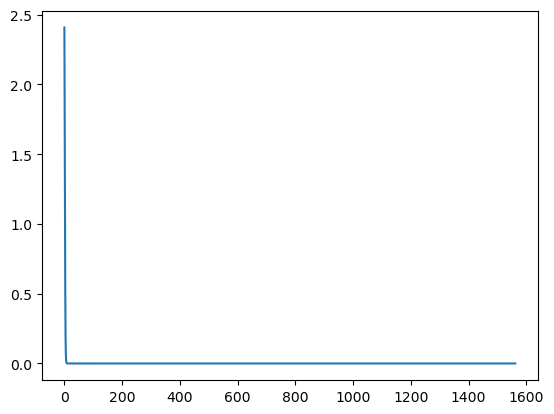

In [47]:
plt.plot(input_independent_losses)

#1: loss: 2.3207729; acc: 0.0312
#2: loss: 1.6367910; acc: 1.0000
#3: loss: 1.0217247; acc: 1.0000
#4: loss: 0.5170361; acc: 1.0000
#5: loss: 0.2153313; acc: 1.0000
#6: loss: 0.0805702; acc: 1.0000
#7: loss: 0.0290987; acc: 1.0000
#8: loss: 0.0105517; acc: 1.0000
#9: loss: 0.0039405; acc: 1.0000
#10: loss: 0.0015435; acc: 1.0000
#11: loss: 0.0006376; acc: 1.0000
#12: loss: 0.0002774; acc: 1.0000
#13: loss: 0.0001271; acc: 1.0000
#14: loss: 0.0000612; acc: 1.0000
#15: loss: 0.0000309; acc: 1.0000
#16: loss: 0.0000162; acc: 1.0000
#17: loss: 0.0000089; acc: 1.0000
#18: loss: 0.0000051; acc: 1.0000
#19: loss: 0.0000030; acc: 1.0000
#20: loss: 0.0000018; acc: 1.0000
#21: loss: 0.0000012; acc: 1.0000
#22: loss: 0.0000008; acc: 1.0000
#23: loss: 0.0000005; acc: 1.0000
#24: loss: 0.0000004; acc: 1.0000
#25: loss: 0.0000003; acc: 1.0000
#26: loss: 0.0000002; acc: 1.0000
#27: loss: 0.0000001; acc: 1.0000
#28: loss: 0.0000001; acc: 1.0000
#29: loss: 0.0000001; acc: 1.0000
#30: loss: 0.0000001; a

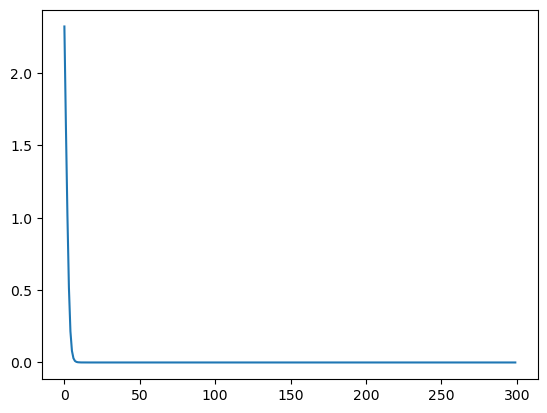

In [13]:
fixed_batch = next(iter(training_dataloader))
fixed_batch_model = Baseline()
fixed_batch_losses=[]

X, y = fixed_batch
X, y = X.to(device), y.to(device)
fixed_batch_model.to(device)
fixed_batch_optimizer = torch.optim.Adam(fixed_batch_model.parameters(), lr=learning_rate)
for i in range(300):
    fixed_batch_optimizer.zero_grad()

    pred = fixed_batch_model(X)
    loss = loss_fn(pred, y)
    fixed_batch_losses.append(loss.item())
    
    loss.backward()
    fixed_batch_optimizer.step()

    acc = (pred.argmax(1) == y).float().mean()
    print(f"#{i+1}: loss: {loss.item():.7f}; acc: {acc:.4f}")


plt.plot(fixed_batch_losses)

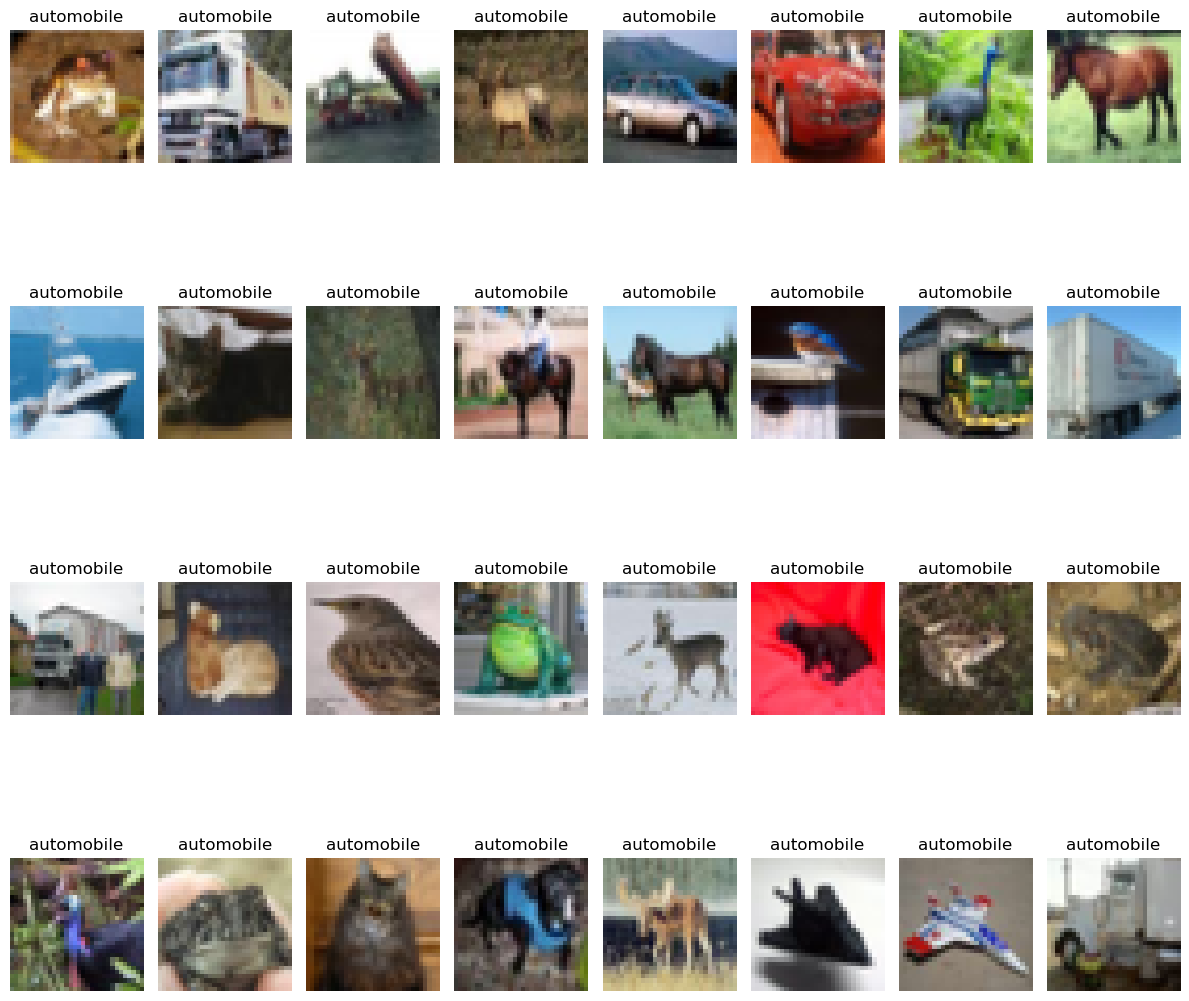

In [14]:
X,_ = next(iter(training_dataloader))

fig, axes = plt.subplots(4, 8, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    img = X[i]


    img = img.permute(1, 2, 0)

    ax.imshow(img.clamp(0, 1))
    ax.set_title(classes[y[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

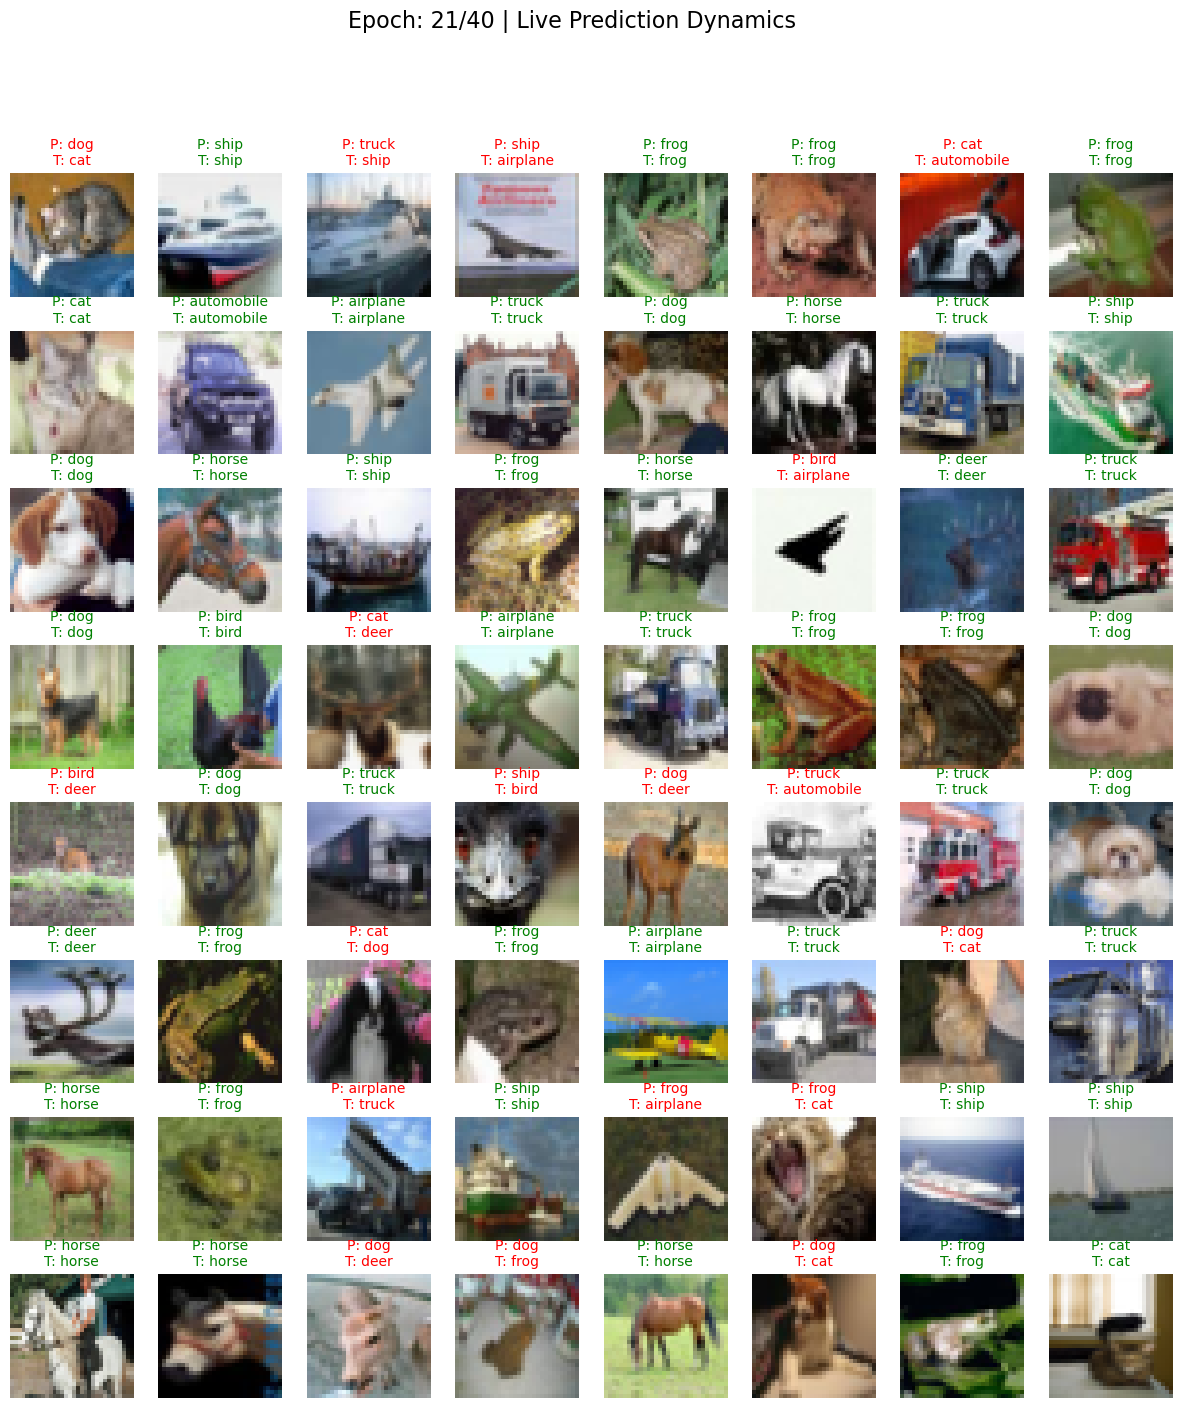

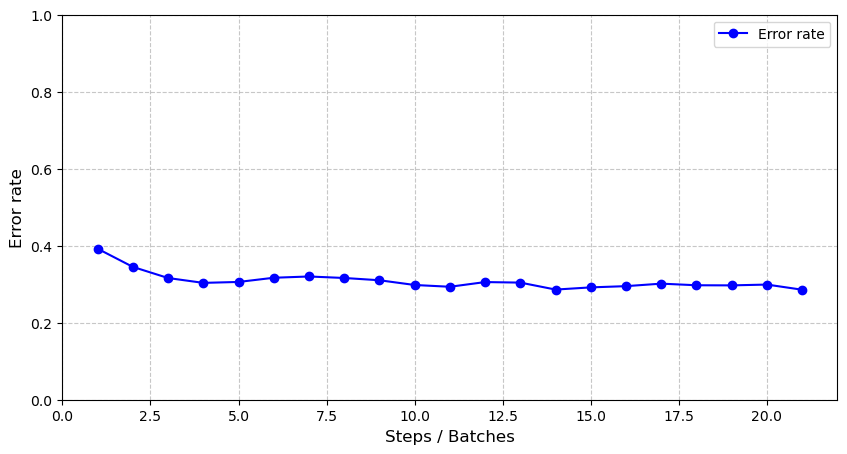

Epoch 1
-----------------------------------
loss: 2.297383 [   32/50000]
loss: 1.818715 [ 3232/50000]
loss: 1.371824 [ 6432/50000]
loss: 1.561250 [ 9632/50000]
loss: 1.301821 [12832/50000]
loss: 1.499671 [16032/50000]
loss: 1.322657 [19232/50000]
loss: 1.425106 [22432/50000]
loss: 1.077561 [25632/50000]
loss: 0.931267 [28832/50000]
loss: 1.228878 [32032/50000]
loss: 1.361620 [35232/50000]
loss: 1.019839 [38432/50000]
loss: 1.052529 [41632/50000]
loss: 1.283847 [44832/50000]
loss: 1.584268 [48032/50000]
Test Error: 
 Accuracy: 60.8%, Avg loss: 1.093152 

Epoch 2
-----------------------------------
loss: 1.014571 [   32/50000]
loss: 1.090643 [ 3232/50000]
loss: 0.927332 [ 6432/50000]
loss: 0.993993 [ 9632/50000]
loss: 0.946087 [12832/50000]
loss: 0.873259 [16032/50000]
loss: 1.039242 [19232/50000]
loss: 1.064802 [22432/50000]
loss: 0.683364 [25632/50000]
loss: 0.629173 [28832/50000]
loss: 1.066538 [32032/50000]
loss: 1.037765 [35232/50000]
loss: 0.727736 [38432/50000]
loss: 0.896452 [416

KeyboardInterrupt: 

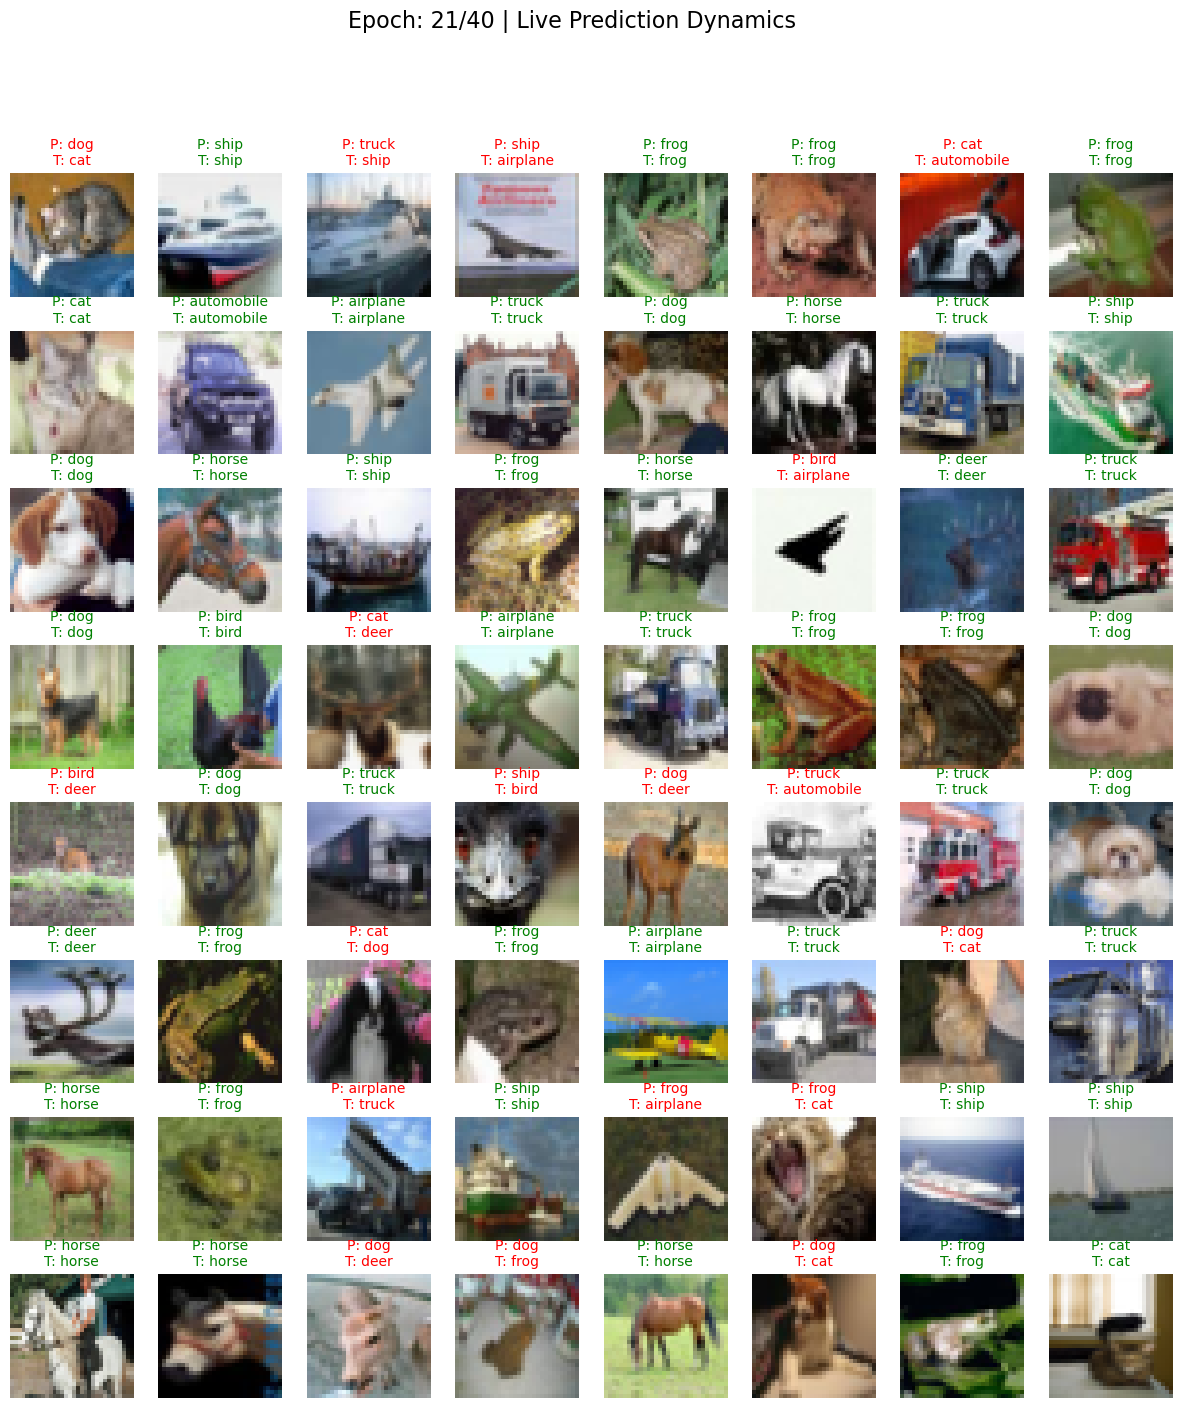

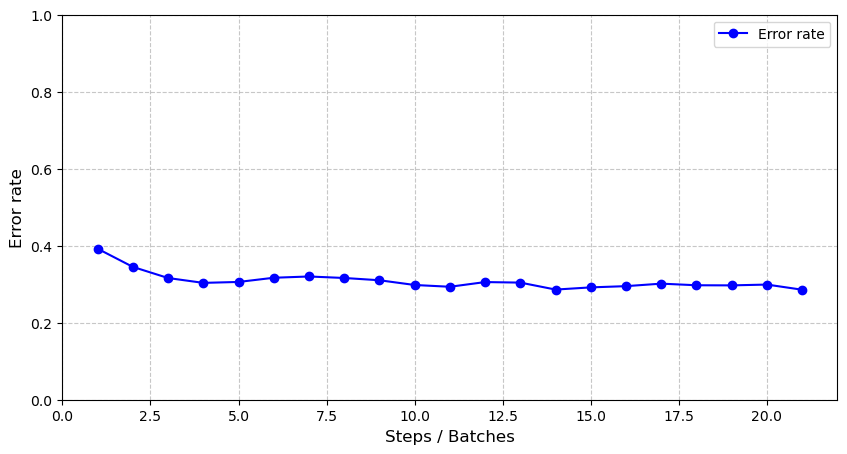

In [29]:
loss_fn = nn.CrossEntropyLoss()
baseline_model = Baseline().to(device)
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=learning_rate)
baseline_losses=[]
baseline_epochs = 40

fig, axes = plt.subplots(8, 8, figsize=(15, 16)) 
axes = axes.flatten()
images_list = []
labels_list = []
total_images = 0

baseline_error_rates = []

for imgs, lbls in test_dataloader:
    images_list.append(imgs)
    labels_list.append(lbls)
    total_images += imgs.size(0) 
    
    if total_images >= 64:
        break

fixed_images = torch.cat(images_list, dim=0)[:64].to(device)
fixed_labels = torch.cat(labels_list, dim=0)[:64].to(device)


num_visualize = min(64, len(fixed_images))

for i in range(num_visualize):
    img = fixed_images[i].cpu().numpy().transpose((1, 2, 0))
    axes[i].imshow(img)
    axes[i].axis('off')
for i in range(num_visualize, len(axes)):
    axes[i].axis('off')

plt.subplots_adjust()

dh = display(fig, display_id=True)

fig_line, ax_line = plt.subplots(figsize=(10, 5))
line, = ax_line.plot([], [], marker='o', linestyle='-', color='blue', label='Error rate')
ax_line.set_xlabel('Steps / Batches', fontsize=12)
ax_line.set_ylabel('Error rate', fontsize=12)
ax_line.set_ylim(0,1)
ax_line.set_xlim(0, 10)
ax_line.grid(True, linestyle='--', alpha=0.7)
ax_line.legend()

dh_line = display(fig_line, display_id=True)


for e in range(baseline_epochs):
    print(f"Epoch {e+1}\n-----------------------------------")
    train_loop(training_dataloader, baseline_model, loss_fn, optimizer, baseline_losses)
    test_loop(test_dataloader, baseline_model, loss_fn, baseline_error_rates)

    baseline_model.eval()
    with torch.no_grad():
        outputs = baseline_model(fixed_images)
        _, preds = torch.max(outputs, 1)


    for i in range(num_visualize):
        pred_label = classes[preds[i].item()]
        true_label = classes[fixed_labels[i].item()]
        color = 'green' if pred_label == true_label else 'red'

        axes[i].set_title(f"P: {pred_label}\nT: {true_label}", color=color, fontsize=10)

    fig.suptitle(f"Epoch: {e + 1}/{baseline_epochs} | Live Prediction Dynamics", fontsize=16, y=0.98)

    dh.update(fig)

    x_data = list(range(1, len(baseline_error_rates) + 1))
    y_data = baseline_error_rates

    line.set_data(x_data, y_data)

    if len(x_data) > ax_line.get_xlim()[1]:
        ax_line.set_xlim(0, len(x_data) + 5)

    dh_line.update(fig_line)

plt.close(fig)
plt.close(fig_line)
print("Done")

In [22]:
loss_fn = nn.CrossEntropyLoss()
model = ResidualNet()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_values = []

for e in range(epochs):
    print(f"Epoch {e+1}\n-----------------------------------")
    train_loop(training_dataloader, model, loss_fn, optimizer, loss_values)
    test_loop(test_dataloader, model, loss_fn)
print("Done")

Epoch 1
-----------------------------------
loss: 2.353781 [   32/50000]
loss: 1.905915 [ 3232/50000]
loss: 1.593484 [ 6432/50000]
loss: 1.950907 [ 9632/50000]
loss: 1.336381 [12832/50000]
loss: 1.676772 [16032/50000]
loss: 1.722548 [19232/50000]
loss: 1.497723 [22432/50000]
loss: 1.447366 [25632/50000]
loss: 0.938363 [28832/50000]
loss: 1.382919 [32032/50000]
loss: 1.390421 [35232/50000]
loss: 1.120200 [38432/50000]
loss: 1.027381 [41632/50000]
loss: 1.259525 [44832/50000]
loss: 1.639313 [48032/50000]
Test Error: 
 Accuracy: 60.4%, Avg loss: 1.118930 

Epoch 2
-----------------------------------
loss: 0.958652 [   32/50000]
loss: 1.116659 [ 3232/50000]
loss: 1.076846 [ 6432/50000]
loss: 1.095126 [ 9632/50000]
loss: 0.782654 [12832/50000]
loss: 1.231777 [16032/50000]
loss: 1.464611 [19232/50000]
loss: 0.964121 [22432/50000]
loss: 0.954914 [25632/50000]
loss: 0.762146 [28832/50000]
loss: 1.177379 [32032/50000]
loss: 0.856923 [35232/50000]
loss: 0.894511 [38432/50000]
loss: 0.880152 [416

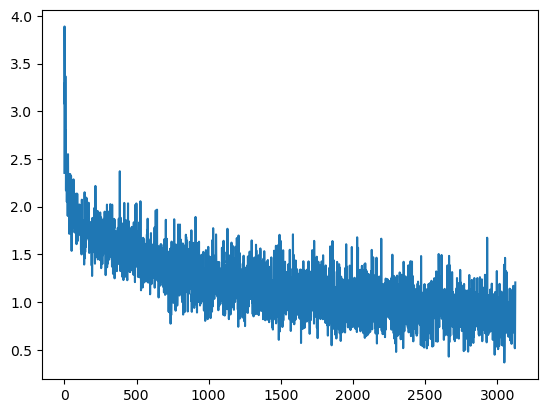

In [23]:
plt.plot(loss_values)